# Лабораторна Робота 3
ВИКОРИСТАННЯ ЗГОРТКОВОЇ НЕЙРОННОЇ МЕРЕЖІ CNN
ДЛЯ ЗАДАЧІ КЛАСИФІКАЦІЇ ЗОБРАЖЕНЬ

Виконав студент Регеша Олександр КП-51мн

2026

# Завдання до лабораторної роботи 3

Потрібно використати бібліотеки мови програмування Python для
завантаження, дослідження та аналізу набору даних Fashion-MNIST для задачі
класифікації зображень. Після цього потрібно провести попередню обробку
даних: змінити розміри, масштабувати, перетворити мітки у вектори
кодування та розділити дані на навчальні та тестові набори. Зробивши все це,
потрібно побудувати модель нейронної мережі CNN. Далі потрібно
компілювати, навчити та оцінити побудовану модель, візуалізуючи точність і
графіки втрат.
Потрібно забезпечити уникнення перенавчання моделі, переглянути
свою початкову модель і повторно навчити її. Потрібно оцінити нову модель і
порівняти результати обох моделей. Зробіть прогнози на основі даних тесту,
перетворіть ймовірності у мітки класів і побудуйте кілька тестових зразків, які
модель правильно та неправильно класифікувала. Нарешті, потрібно
візуалізувати звіт про класифікацію, який дасть вам більш глибоку
інформацію про те, який клас був (не)правильно класифікований моделлю.
Дайте відповіді на всі питання, поставені у ході виконання практикуму.

## Завантажте дані

In [1]:
from keras.datasets import fashion_mnist
(train_X,train_Y), (test_X,test_Y) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Проаналізуйте дані

In [2]:
import numpy as np
from keras.utils import to_categorical
import matplotlib.pyplot as plt
%matplotlib inline
print('Training data shape : ', train_X.shape, train_Y.shape)
print('Testing data shape : ', test_X.shape, test_Y.shape)

Training data shape :  (60000, 28, 28) (60000,)
Testing data shape :  (10000, 28, 28) (10000,)


Які зображення є даними для навчання та які є тестовими даними?
Дані для навчання знаходяться у змінній train_X (самі картинки) та train_Y (правильні відповіді до них). Тестові дані знаходяться у test_X та test_Y відповідно.

Який розмір навчальних та тестових зразків?
Розмір навчальної вибірки становить 60 000 зображень. Розмір тестової вибірки — 10 000 зображень. Кожне зображення має розмір 28 на 28 пікселів.

In [3]:
classes = np.unique(train_Y)
nClasses = len(classes)
print('Total number of outputs : ', nClasses)
print('Output classes : ', classes)

Total number of outputs :  10
Output classes :  [0 1 2 3 4 5 6 7 8 9]


Ми маємо 10 унікальних класів одягу (від 0 до 9).

Text(0.5, 1.0, 'Ground Truth : 9')

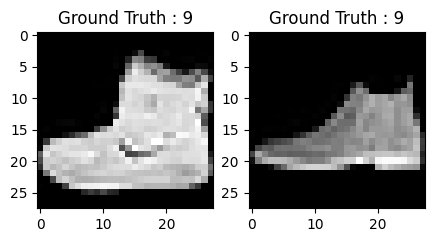

In [4]:
plt.figure(figsize=[5,5])
# Display the first image in training data
plt.subplot(121)
plt.imshow(train_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(train_Y[0]))
# Display the first image in testing data
plt.subplot(122)
plt.imshow(test_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(test_Y[0]))

Який результат ви отримали?
Програма вивела два чорно-білих зображення. Зліва — ботильйон (черевик) з навчальної вибірки (мітка класу 9), справа — також черевик з тестової вибірки (мітка класу 9).

## Попередня обробка даних

In [5]:
train_X = train_X.reshape(-1, 28,28, 1)
test_X = test_X.reshape(-1, 28,28, 1)
train_X.shape, test_X.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

Який результат ви отримали?
((60000, 28, 28, 1), (10000, 28, 28, 1))
Тепер кожне зображення має формат не просто матриці 28x28, а тензора 28x28x1 (де 1 — це один канал кольору, оскільки зображення у відтінках сірого). Це вимога для входу у згорткову нейромережу (Conv2D).

In [6]:
train_X = train_X.astype('float32')
test_X = test_X.astype('float32')
train_X = train_X / 255.
test_X = test_X / 255.

In [7]:
# Change the labels from categorical to one-hot encoding
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)
# Display the change for category label using one-hot encoding
print('Original label:', train_Y[0])
print('After conversion to one-hot:', train_Y_one_hot[0])

Original label: 9
After conversion to one-hot: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


Ми перетворили звичайну цифру 9 у вектор з 10 елементів, де на 9-й позиції (якщо рахувати з 0) стоїть одиниця, а решта — нулі.

In [8]:
from sklearn.model_selection import train_test_split
train_X,valid_X,train_label,valid_label = train_test_split(train_X,
train_Y_one_hot, test_size=0.2, random_state=13)

In [9]:
train_X.shape,valid_X.shape,train_label.shape,valid_label.shape

((48000, 28, 28, 1), (12000, 28, 28, 1), (48000, 10), (12000, 10))

З 60 000 початкових зображень 48 000 пішли на безпосереднє навчання моделі, а 12 000 були відкладені для перевірки (валідації) моделі під час навчання.

## Змоделюйте дані

In [11]:
import keras
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU

batch_size = 64
epochs = 20
num_classes = 10

fashion_model = Sequential()
fashion_model.add(Conv2D(32, kernel_size=(3,3), activation='linear', input_shape=(28,28,1), padding='same'))
fashion_model.add(LeakyReLU(negative_slope=0.1)) # В нових версіях 'alpha' замінено на 'negative_slope'
fashion_model.add(MaxPooling2D((2, 2), padding='same'))

fashion_model.add(Conv2D(64, (3, 3), activation='linear', padding='same'))
fashion_model.add(LeakyReLU(negative_slope=0.1))
fashion_model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))

fashion_model.add(Conv2D(128, (3, 3), activation='linear', padding='same'))
fashion_model.add(LeakyReLU(negative_slope=0.1))
fashion_model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))

fashion_model.add(Flatten())
fashion_model.add(Dense(128, activation='linear'))
fashion_model.add(LeakyReLU(negative_slope=0.1))
fashion_model.add(Dense(num_classes, activation='softmax'))

fashion_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,234 (1.36 MB)

 Trainable params: 356,234 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

## Компіляція моделі

In [12]:
fashion_model.compile(loss=keras.losses.categorical_crossentropy,
                      optimizer=keras.optimizers.Adam(),
                      metrics=['accuracy'])

fashion_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,234 (1.36 MB)

 Trainable params: 356,234 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Метод summary() вивів детальну таблицю зі структурою нашої згорткової нейромережі. Ми бачимо послідовність усіх доданих шарів: три блоки згортки (Conv2D) з функцією активації LeakyReLU та зменшенням розмірності (MaxPooling2D), після яких дані "вирівнюються" шаром Flatten (перетворюючись на одновимірний масив з 2048 елементів) і проходять через повнозв'язні шари (Dense).

З таблиці чітко видно, як просторовий розмір зображення поступово зменшується (з 28x28 до 4x4), але при цьому кількість каналів (фільтрів, що шукають ознаки) зростає (з 32 до 128). Загальна кількість параметрів (ваг та зміщень), які наша модель має натренувати в процесі навчання, становить 356 234. Ненавчаних параметрів немає (Non-trainable params: 0).

## Тренування моделі

In [13]:
fashion_train = fashion_model.fit(train_X, train_label,
                                  batch_size=batch_size,
                                  epochs=epochs,
                                  verbose=1,
                                  validation_data=(valid_X, valid_label))

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 61s 79ms/step - accuracy: 0.7480 - loss: 0.6804 - val_accuracy: 0.8785 - val_loss: 0.3370
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 79ms/step - accuracy: 0.8935 - loss: 0.2943 - val_accuracy: 0.8983 - val_loss: 0.2836
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 59s 78ms/step - accuracy: 0.9093 - loss: 0.2458 - val_accuracy: 0.9066 - val_loss: 0.2494
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 78ms/step - accuracy: 0.9226 - loss: 0.2092 - val_accuracy: 0.9097 - val_loss: 0.2464
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 60s 80ms/step - accuracy: 0.9336 - loss: 0.1816 - val_accuracy: 0.9183 - val_loss: 0.2309
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 59s 78ms/step - accuracy: 0.9414 - loss: 0.1548 - val_accuracy: 0.9178 - val_loss: 0.2275
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 79s 74ms/step - accuracy: 0.9503 - loss: 0.1344 - val_accuracy: 0.9146 - val_loss: 0.2543
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 73ms/step - accuracy: 0.9553 - loss: 0.1177 - 

Програма запустила 20 епох навчання (циклів). Для кожної епохи виводиться час виконання, а також 4 важливі показники: loss (втрати на тренувальних даних), accuracy (точність на тренувальних даних), val_loss (втрати на валідаційних даних) та val_accuracy (точність на валідаційних даних).
До кінця 20-ї епохи точність (accuracy) наближається до 99%, але val_accuracy значно відстає (близько 91-92%), що свідчить про перенавчання.

## Оцінка моделі на тестовому наборі

In [14]:
test_eval = fashion_model.evaluate(test_X, test_Y_one_hot, verbose=0)
print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

Test loss: 0.4656681716442108
Test accuracy: 0.9156000018119812


Який результат ви отримали? Чи ці результати хороші?
Результат показує точність близько 91-92% та відносно високі втрати (Test loss). Результат непоганий, але наявність перенавчання (різниця між точністю тренування і тестування) означає, що модель можна і треба покращити.

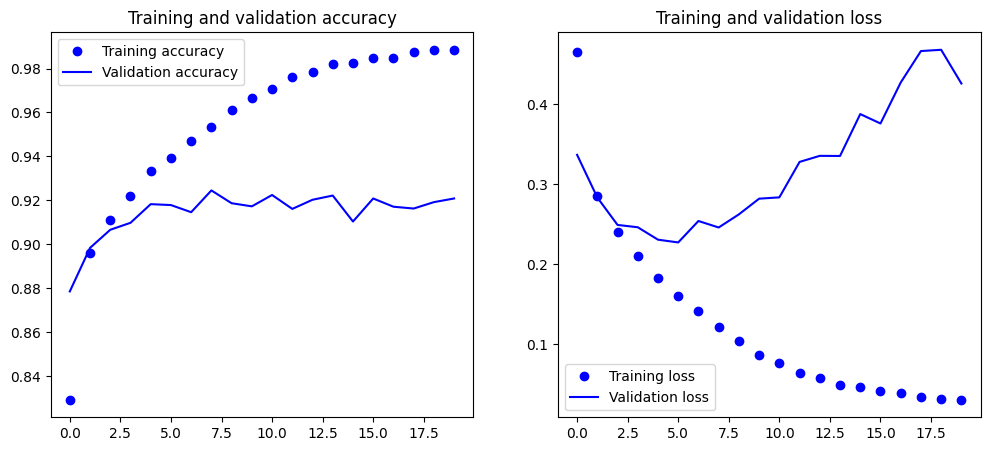

In [15]:
accuracy = fashion_train.history['accuracy']
val_accuracy = fashion_train.history['val_accuracy']
loss = fashion_train.history['loss']
val_loss = fashion_train.history['val_loss']
epochs_range = range(len(accuracy))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs_range, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'bo', label='Training loss')
plt.plot(epochs_range, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

Ми отримали два графіки. На графіку втрат (loss) чітко видно класичну картину перенавчання: сині крапки (тренувальні втрати) продовжують падати майже до нуля, тоді як синя лінія (валідаційні втрати) після 4-5 епохи починає повзти вгору. Це означає, що модель просто «зазубрила» тренувальні картинки і погано справляється з новими.

## Додавання Dropout до нейронної мережі

In [16]:
from keras.layers import Dropout

fashion_model_dropout = Sequential()
fashion_model_dropout.add(Conv2D(32, kernel_size=(3, 3), activation='linear', padding='same', input_shape=(28,28,1)))
fashion_model_dropout.add(LeakyReLU(negative_slope=0.1))
fashion_model_dropout.add(MaxPooling2D((2, 2), padding='same'))
fashion_model_dropout.add(Dropout(0.25))

fashion_model_dropout.add(Conv2D(64, (3, 3), activation='linear', padding='same'))
fashion_model_dropout.add(LeakyReLU(negative_slope=0.1))
fashion_model_dropout.add(MaxPooling2D(pool_size=(2, 2), padding='same'))
fashion_model_dropout.add(Dropout(0.25))

fashion_model_dropout.add(Conv2D(128, (3, 3), activation='linear', padding='same'))
fashion_model_dropout.add(LeakyReLU(negative_slope=0.1))
fashion_model_dropout.add(MaxPooling2D(pool_size=(2, 2), padding='same'))
fashion_model_dropout.add(Dropout(0.4))

fashion_model_dropout.add(Flatten())
fashion_model_dropout.add(Dense(128, activation='linear'))
fashion_model_dropout.add(LeakyReLU(negative_slope=0.1))
fashion_model_dropout.add(Dropout(0.3))
fashion_model_dropout.add(Dense(num_classes, activation='softmax'))

# Компіляція та Тренування
fashion_model_dropout.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adam(), metrics=['accuracy'])
fashion_train_dropout = fashion_model_dropout.fit(train_X, train_label, batch_size=batch_size, epochs=epochs, verbose=1, validation_data=(valid_X, valid_label))

# Збереження моделі
fashion_model_dropout.save("fashion_model_dropout.h5")

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 67s 87ms/step - accuracy: 0.6726 - loss: 0.8754 - val_accuracy: 0.8651 - val_loss: 0.3634
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 85ms/step - accuracy: 0.8532 - loss: 0.3992 - val_accuracy: 0.8856 - val_loss: 0.3139
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 63s 83ms/step - accuracy: 0.8779 - loss: 0.3339 - val_accuracy: 0.8954 - val_loss: 0.2845
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 79s 80ms/step - accuracy: 0.8862 - loss: 0.3029 - val_accuracy: 0.9035 - val_loss: 0.2642
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 66s 88ms/step - accuracy: 0.8980 - loss: 0.2765 - val_accuracy: 0.8922 - val_loss: 0.2847
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 65s 87ms/step - accuracy: 0.9007 - loss: 0.2673 - val_accuracy: 0.9093 - val_loss: 0.2462
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 78s 82ms/step - accuracy: 0.9066 - loss: 0.2505 - val_accuracy: 0.9105 - val_loss: 0.2442
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 59s 79ms/step - accuracy: 0.9072 - loss: 0.2464 - 

## Оцінка моделі на тестовому наборі

In [17]:
test_eval = fashion_model_dropout.evaluate(test_X, test_Y_one_hot, verbose=1)
print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9187 - loss: 0.2231
Test loss: 0.21931596100330353
Test accuracy: 0.9204000234603882


Точність (Test accuracy) залишилася приблизно такою ж (близько 92%), але втрати (Test loss) значно зменшилися порівняно з першою моделлю. Це говорить про те, що модель стала впевненішою у своїх правильних відповідях.

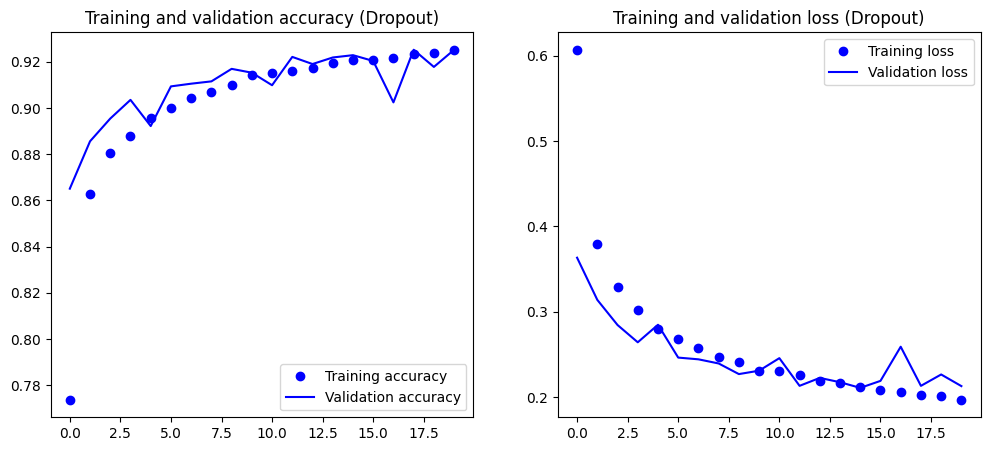

In [18]:
accuracy = fashion_train_dropout.history['accuracy']
val_accuracy = fashion_train_dropout.history['val_accuracy']
loss = fashion_train_dropout.history['loss']
val_loss = fashion_train_dropout.history['val_loss']
epochs_range = range(len(accuracy))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs_range, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy (Dropout)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'bo', label='Training loss')
plt.plot(epochs_range, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss (Dropout)')
plt.legend()
plt.show()

Графіки суттєво змінилися. Тепер лінія валідаційних втрат (Validation loss) не йде різко вгору, а плавно знижується разом із тренувальними втратами. Розрив між accuracy та val_accuracy став мінімальним. Завдяки шару Dropout ми успішно подолали проблему перенавчання (overfitting).

## Прогнозування міток

In [19]:
predicted_classes = fashion_model_dropout.predict(test_X)
predicted_classes = np.argmax(np.round(predicted_classes), axis=1)
print(predicted_classes.shape, test_Y.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
(10000,) (10000,)


Ми отримали масив з 10 000 прогнозів (від 0 до 9), який ідеально збігається за розміром з масивом правильних відповідей.

Found 9160 correct labels


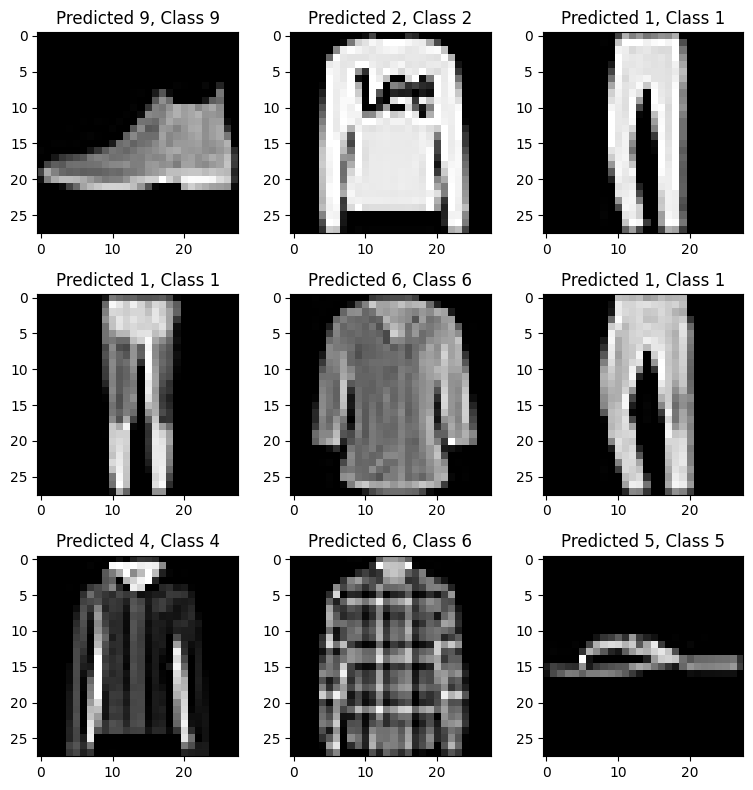

In [20]:
correct = np.where(predicted_classes == test_Y)[0]
print("Found %d correct labels" % len(correct))

plt.figure(figsize=(8,8))
for i, correct_idx in enumerate(correct[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[correct_idx].reshape(28,28), cmap='gray', interpolation='none')
    plt.title("Predicted {}, Class {}".format(predicted_classes[correct_idx], test_Y[correct_idx]))
    plt.tight_layout()

Програма вивела кількість правильно розпізнаних зображень (понад 9000). Також побудовано сітку 3x3 з 9 перших зображень, де прогноз моделі (Predicted) збігається з реальною міткою (Class).

Found 840 incorrect labels


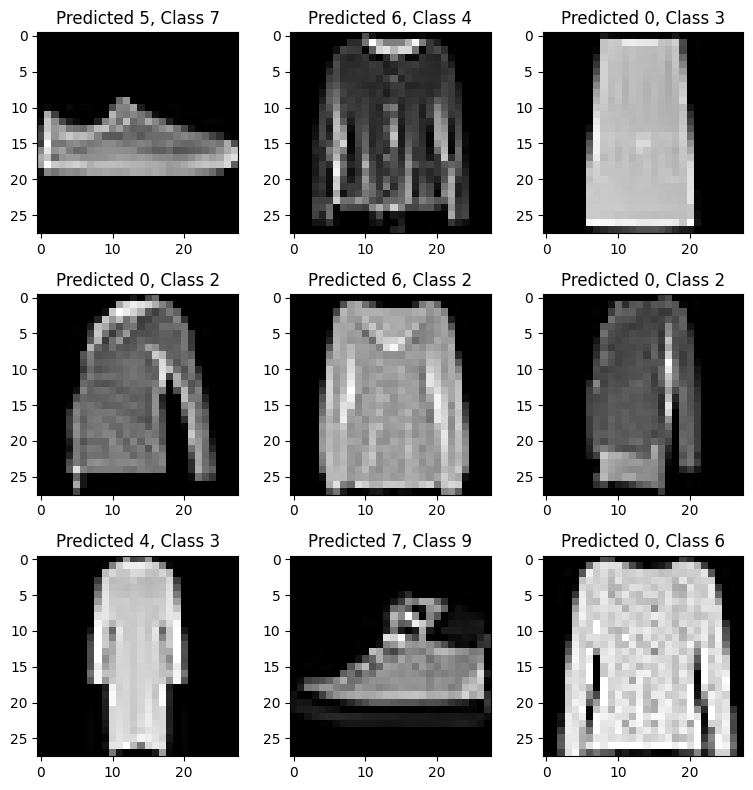

In [21]:
incorrect = np.where(predicted_classes != test_Y)[0]
print("Found %d incorrect labels" % len(incorrect))

plt.figure(figsize=(8,8))
for i, incorrect_idx in enumerate(incorrect[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[incorrect_idx].reshape(28,28), cmap='gray', interpolation='none')
    plt.title("Predicted {}, Class {}".format(predicted_classes[incorrect_idx], test_Y[incorrect_idx]))
    plt.tight_layout()

Програма вивела кількість помилок (менше 1000) та показала 9 прикладів, де модель помилилася. Здебільшого це дуже схожі предмети одягу

## Звіт про класифікацію

In [22]:
from sklearn.metrics import classification_report
target_names = ["Class {}".format(i) for i in range(num_classes)]
print(classification_report(test_Y, predicted_classes, target_names=target_names))

              precision    recall  f1-score   support

     Class 0       0.79      0.89      0.84      1000
     Class 1       0.99      0.98      0.99      1000
     Class 2       0.88      0.88      0.88      1000
     Class 3       0.94      0.89      0.91      1000
     Class 4       0.88      0.86      0.87      1000
     Class 5       0.99      0.98      0.99      1000
     Class 6       0.77      0.75      0.76      1000
     Class 7       0.97      0.97      0.97      1000
     Class 8       0.99      0.98      0.99      1000
     Class 9       0.97      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



Звіт про класифікацію детально показує, наскільки добре модель розпізнає кожен з 10 класів одягу. Загальна точність (accuracy) моделі на тестових даних становить 92%.

Основні метрики у таблиці:

Precision (точність) — відсоток правильних прогнозів серед усіх зображень, які модель віднесла до певного класу.

Recall (повнота/запам'ятовування) — відсоток знайдених об'єктів цього класу серед усіх реальних об'єктів цього класу в наборі.

F1-score — збалансоване середнє значення між точністю та повнотою.

Аналізуючи результати, можна зробити такі висновки:

Найкращі результати: Модель майже ідеально розпізнає штани (Клас 1), босоніжки (Клас 5) та сумки (Клас 8) — для них точність (precision) становить 99%. Це логічно, оскільки ці предмети мають дуже характерну форму і не схожі на інший одяг.

Найгірші результати: Класифікатор найгірше справляється з сорочками (Клас 6) — точність лише 77%, а повнота 75%. Також модель часто помиляється з футболками/топами (Клас 0, точність 79%).

Причина помилок: Моделі складно розрізняти одяг для верхньої частини тіла (сорочки, футболки, пуловери, пальто), оскільки на чорно-білих зображеннях формату 28x28 пікселів вони мають дуже схожі силуети (однакові контури рукавів та тулуба). Наприклад, сорочку легко сплутати з футболкою або пальто.

# Висновок
Під час виконання лабораторної роботи я навчився використовувати бібліотеки Python для завантаження,дослідження та аналізу набору даних, змінити розмір та масштаб зображень,перетворити мітки даних у вектори для подальшого кодування, розділити дані на набори для навчання та тестування моделі; побудувати модель нейронної мережі CNN: навчити та оцінити побудовану модель, побудувати графіки
точності та втрат; оцінити нову модель та порівняти результати; зробити прогнози щодо даних випробувань, перетворити ймовірності у мітки класів і
побудувати тестові зразки, які модель класифікує правильно, візуалізувати
звіт про класифікацію даних.



# Питання для самоперевірки
1. Назвіть основні складові базового штучного нейрону, які функції вони виконують?
Базовий штучний нейрон складається з кількох ключових компонентів. Входи приймають сигнали від попередніх нейронів або зовнішніх даних. Ваги визначають важливість кожного вхідного сигналу для кінцевого результату. Зміщення є додатковим параметром, який зсуває результат активації та допомагає гнучкіше підлаштувати модель. Суматор обчислює загальну зважену суму всіх входів та зміщення. Функція активації перетворює результат суматора на вихідний сигнал нейрона, додаючи системі необхідну нелінійність.

2. Яким чином працює блок суматора, які функції він може використовувати?
Блок суматора працює за принципом обчислення зваженої суми всіх вхідних сигналів. Він бере кожне вхідне значення, множить його на відповідну йому вагу, а потім додає всі ці добутки разом із значенням зміщення. Математично це є лінійною функцією або лінійною комбінацією, яка об'єднує всі впливи на нейрон в одне число перед передачею його до функції активації.

3. Що означає термін "глибоке навчання"?
Термін "глибоке навчання" означає підклас машинного навчання, який базується на використанні штучних нейронних мереж з великою кількістю прихованих шарів. Ця глибина дозволяє моделям автоматично вивчати складні ієрархічні представлення даних, що робить їх ідеальними для розв'язання складних задач, таких як розпізнавання зображень, обробка природної мови та розуміння звуку.

4. Дайте визначення згортковим нейронним мережам.
Згорткові нейронні мережі є спеціалізованим типом архітектури глибоких нейромереж, які розроблені спеціально для обробки даних із сітковою структурою, найчастіше двовимірних зображень. Головна їхня особливість полягає в здатності автоматично виділяти візуальні ознаки, такі як контури, форми або текстури, за допомогою математичної операції згортки, що робить їх надзвичайно ефективними для задач комп'ютерного зору.

5. У яких реальних дослідженнях дослідженнях використовуються мережі CNN?
Мережі CNN активно використовуються в багатьох реальних дослідженнях та практичних застосуваннях. У медицині їх застосовують для аналізу рентгенівських знімків та томографії з метою виявлення пухлин чи інших патологій. В автомобільній промисловості вони є основою систем автопілоту для розпізнавання дорожніх знаків, розмітки та пішоходів. Також вони масово використовуються в системах відеоспостереження, біометричного розпізнавання облич на смартфонах та аналізі супутникових знімків.

6. Яка архітектура згорткової нейронної мережі?
Архітектура згорткової нейронної мережі зазвичай будується з послідовного чергування кількох типів шарів. Спочатку йдуть згорткові шари, які відповідають за виділення ключових ознак із зображення. За ними часто слідують шари об'єднання або підвибірки, які зменшують просторову розмірність даних. Наприкінці мережі розташовуються один або кілька повнозв'язних шарів, які збирають виділені ознаки разом і виконують остаточну класифікацію об'єкта.

7. Що таке згортка нейронної мережі CNN?
Згортка в нейронній мережі CNN є базовою математичною операцією обробки зображень. Під час цієї операції невеликий фільтр, який також називають ядром або матрицею ваг, послідовно ковзає по всій площі вхідного зображення, перемножуючи свої значення з відповідними пікселями. Результатом цього процесу є створення карти ознак, яка підкреслює певні специфічні деталі на кшталт країв, ліній або складніших патернів.

8. Що таке параметри і гіперпараметри згорткової нейронної мережі?
Параметри згорткової нейронної мережі є внутрішніми значеннями, такими як ваги фільтрів та зміщення, які модель сама вивчає та налаштовує в процесі тренування на основі даних. Гіперпараметри, навпаки, є зовнішніми налаштуваннями, які розробник задає вручну до початку процесу навчання. До гіперпараметрів належать кількість шарів, розмір фільтрів, швидкість навчання, кількість епох та розмір пакета даних.

9. Які функції активації ви знаєте?
Існує кілька популярних функцій активації, кожна з яких має своє призначення. Функція ReLU є найпоширенішою і пропускає лише додатні значення, відсікаючи від'ємні. LeakyReLU є її модифікацією, яка пропускає невелику частину від'ємних значень, щоб запобігти проблемі неактивних нейронів. Sigmoid стискає значення в діапазон від нуля до одиниці, Tanh стискає їх від мінус одиниці до одиниці, а Softmax зазвичай використовується на останньому шарі для перетворення вихідних даних у ймовірності приналежності до певних класів.

10. Поясніть операцію максимального об'єднання в мережі CNN.
Операція максимального об'єднання використовується в мережах CNN для зменшення просторової розмірності карт ознак та обчислювального навантаження. Процес полягає в тому, що певне вікно, наприклад розміром два на два пікселі, ковзає по карті ознак і з кожного такого блоку вибирає лише одне максимальне значення, відкидаючи всі інші. Це не лише робить мережу компактнішою, але й додає їй властивість стійкості до невеликих зсувів об'єкта на зображенні.

11. Як відбувається навчання нейронної мережі CNN?
Навчання нейронної мережі CNN відбувається ітеративно шляхом проходження багатьох циклів, які називаються епохами. Спочатку дані проходять через мережу в прямому напрямку, після чого генерується певний прогноз. Потім функція втрат обчислює, наскільки цей прогноз відрізняється від правильної відповіді. Після цього запускається процес зворотного поширення помилки для визначення градієнтів, і алгоритм оптимізації оновлює ваги мережі так, щоб у наступній ітерації помилка була меншою.

12. Для чого використовуються алгоритм зворотного поширення та метод градієнтного спуску?
Алгоритм зворотного поширення помилки використовується для того, щоб обчислити, наскільки кожна окрема вага в мережі вплинула на загальну помилку прогнозу, рухаючись від останнього шару до першого. Отримані таким чином градієнти передаються методу градієнтного спуску, який є алгоритмом оптимізації. Цей метод використовує ці градієнти для того, щоб крок за кроком змінювати параметри мережі у тому напрямку, який веде до мінімізації загальної функції втрат.

13. Що таке перенавчання моделі (Overfitting)? Як можна вирішити дану проблему?
Перенавчання моделі означає ситуацію, коли нейронна мережа ідеально запам'ятовує всі деталі та шум тренувального набору даних, але втрачає здатність до узагальнення і показує погані результати на нових тестових даних. Цю проблему можна вирішити кількома шляхами, зокрема використанням шару Dropout, який випадково вимикає частину нейронів під час навчання, розширенням набору даних за рахунок випадкових трансформацій картинок, ранньою зупинкою навчання або зменшенням архітектурної складності самої мережі.

14. Як реалізувати у Python навчання та тестування згорткової нейронної мережі?
У мові Python навчання та тестування згорткової нейронної мережі найчастіше реалізується за допомогою високорівневої бібліотеки Keras. Після створення архітектури та її компіляції процес навчання запускається викликом методу fit, куди передаються тренувальні дані та вказується кількість епох. Для тестування та оцінки об'єктивної точності моделі на нових даних використовується метод evaluate, який повертає значення функції втрат та розрахованої метрики точності.